# Custom Optimizer and Training Loop

This notebook covers **Part 2 (x-xi)** of the assignment on advanced deep learning customization.

**Topics covered:**
- **Custom Optimizer**: SGD with momentum, AdaGrad, RMSprop, Adam from scratch
- **Custom Training Loop**: GradientTape, manual forward/backward pass, gradient accumulation
- **Advanced techniques**: Gradient clipping, mixed precision, distributed training basics

**Framework:** TensorFlow/Keras

**Dataset:** Fashion MNIST

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.19.0


In [2]:
# Load Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

X_val, y_val = X_train[:5000], y_train[:5000]
X_train, y_train = X_train[5000:], y_train[5000:]

# Create tf.data datasets
BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
## Part 1: Custom Optimizers

In [3]:
class CustomSGD(keras.optimizers.Optimizer):
    """SGD with momentum from scratch."""

    def __init__(self, learning_rate=0.01, momentum=0.9, name='CustomSGD', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.momentum = momentum

    def build(self, var_list):
        super().build(var_list)
        if hasattr(self, '_built') and self._built:
            return
        self.velocities = []
        for var in var_list:
            self.velocities.append(self.add_variable_from_reference(var, 'velocity'))
        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        idx = self._get_variable_index(variable)
        velocity = self.velocities[idx]

        # v = momentum * v - lr * gradient
        velocity.assign(self.momentum * velocity - learning_rate * gradient)
        # w = w + v
        variable.assign_add(velocity)

    def _get_variable_index(self, variable):
        return self._trainable_variables.index(variable)

    def get_config(self):
        config = super().get_config()
        config.update({'momentum': self.momentum})
        return config

In [4]:
class CustomAdam(keras.optimizers.Optimizer):
    """Adam optimizer from scratch."""

    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, name='CustomAdam', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon

    def build(self, var_list):
        super().build(var_list)
        if hasattr(self, '_built') and self._built:
            return

        self.m = []  # First moment
        self.v = []  # Second moment

        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, 'm'))
            self.v.append(self.add_variable_from_reference(var, 'v'))

        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        idx = self._get_variable_index(variable)
        m = self.m[idx]
        v = self.v[idx]

        t = tf.cast(self.iterations + 1, tf.float32)

        # Update biased first moment estimate
        m.assign(self.beta_1 * m + (1 - self.beta_1) * gradient)
        # Update biased second moment estimate
        v.assign(self.beta_2 * v + (1 - self.beta_2) * tf.square(gradient))

        # Bias correction
        m_hat = m / (1 - tf.pow(self.beta_1, t))
        v_hat = v / (1 - tf.pow(self.beta_2, t))

        # Update weights
        variable.assign_sub(learning_rate * m_hat / (tf.sqrt(v_hat) + self.epsilon))

    def _get_variable_index(self, variable):
        return self._trainable_variables.index(variable)

    def get_config(self):
        config = super().get_config()
        config.update({
            'beta_1': self.beta_1,
            'beta_2': self.beta_2,
            'epsilon': self.epsilon
        })
        return config

In [5]:
class AdamW(keras.optimizers.Optimizer):
    """Adam with decoupled weight decay."""

    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, weight_decay=0.01, name='AdamW', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon
        self.weight_decay = weight_decay

    def build(self, var_list):
        super().build(var_list)
        if hasattr(self, '_built') and self._built:
            return

        self.m = []
        self.v = []

        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, 'm'))
            self.v.append(self.add_variable_from_reference(var, 'v'))

        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        idx = self._get_variable_index(variable)
        m = self.m[idx]
        v = self.v[idx]

        t = tf.cast(self.iterations + 1, tf.float32)

        # Adam update
        m.assign(self.beta_1 * m + (1 - self.beta_1) * gradient)
        v.assign(self.beta_2 * v + (1 - self.beta_2) * tf.square(gradient))

        m_hat = m / (1 - tf.pow(self.beta_1, t))
        v_hat = v / (1 - tf.pow(self.beta_2, t))

        # Decoupled weight decay
        variable.assign_sub(learning_rate * (m_hat / (tf.sqrt(v_hat) + self.epsilon) + self.weight_decay * variable))

    def _get_variable_index(self, variable):
        return self._trainable_variables.index(variable)

    def get_config(self):
        config = super().get_config()
        config.update({
            'beta_1': self.beta_1,
            'beta_2': self.beta_2,
            'epsilon': self.epsilon,
            'weight_decay': self.weight_decay
        })
        return config

In [17]:
# Test custom optimizers
def create_model():
    return keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

class FixedCustomSGD(keras.optimizers.Optimizer):
    """SGD with momentum from scratch (fixed version for Keras)."""

    def __init__(self, learning_rate=0.01, momentum=0.9, name='FixedCustomSGD', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.momentum = momentum

    def build(self, var_list):
        super().build(var_list)
        if hasattr(self, '_built') and self._built:
            return
        # Create and store slot variables in a list
        self.velocities = [self.add_variable_from_reference(var, 'velocity') for var in var_list]
        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        # Get the index of the variable to retrieve the corresponding velocity
        idx = self._get_variable_index(variable)
        velocity = self.velocities[idx]

        # v = momentum * v - lr * gradient
        velocity.assign(self.momentum * velocity - learning_rate * gradient)
        # w = w + v
        variable.assign_add(velocity)

    def get_config(self):
        config = super().get_config()
        config.update({'momentum': self.momentum})
        return config

# Train with FixedCustomSGD
print("Training with FixedCustomSGD...")
model_sgd = create_model()
model_sgd.compile(optimizer=FixedCustomSGD(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(train_ds, epochs=5, validation_data=val_ds, verbose=1)


Training with FixedCustomSGD...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


860/860 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7974 - loss: 0.5723 - val_accuracy: 0.8526 - val_loss: 0.4117
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8494 - loss: 0.4108 - val_accuracy: 0.8670 - val_loss: 0.3653
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8659 - loss: 0.3701 - val_accuracy: 0.8684 - val_loss: 0.3669
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8742 - loss: 0.3442 - val_accuracy: 0.8726 - val_loss: 0.3450
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8815 - loss: 0.3259 - val_accuracy: 0.8728 - val_loss: 0.3390


In [19]:
class CustomAdam(keras.optimizers.Optimizer):
    """Adam optimizer from scratch (fixed for graph mode)."""

    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, name='CustomAdam', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon

    def build(self, var_list):
        super().build(var_list)
        if hasattr(self, '_built') and self._built:
            return

        self.m = []  # First moment
        self.v = []  # Second moment

        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, 'm'))
            self.v.append(self.add_variable_from_reference(var, 'v'))

        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        idx = self._get_variable_index(variable)
        m = self.m[idx]
        v = self.v[idx]

        t = tf.cast(self.iterations + 1, tf.float32)

        # Update biased first moment estimate
        m.assign(self.beta_1 * m + (1 - self.beta_1) * gradient)
        # Update biased second moment estimate
        v.assign(self.beta_2 * v + (1 - self.beta_2) * tf.square(gradient))

        # Bias correction
        m_hat = m / (1 - tf.pow(self.beta_1, t))
        v_hat = v / (1 - tf.pow(self.beta_2, t))

        # Update weights
        variable.assign_sub(learning_rate * m_hat / (tf.sqrt(v_hat) + self.epsilon))

    def get_config(self):
        config = super().get_config()
        config.update({
            'beta_1': self.beta_1,
            'beta_2': self.beta_2,
            'epsilon': self.epsilon
        })
        return config

# Train with CustomAdam
print("\nTraining with CustomAdam...")
model_adam = create_model()
model_adam.compile(optimizer=CustomAdam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(train_ds, epochs=5, validation_data=val_ds, verbose=1)



Training with CustomAdam...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


860/860 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8157 - loss: 0.5226 - val_accuracy: 0.8642 - val_loss: 0.3844
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8623 - loss: 0.3841 - val_accuracy: 0.8556 - val_loss: 0.3900
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8743 - loss: 0.3451 - val_accuracy: 0.8784 - val_loss: 0.3314
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8831 - loss: 0.3177 - val_accuracy: 0.8782 - val_loss: 0.3345
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8883 - loss: 0.2992 - val_accuracy: 0.8840 - val_loss: 0.3138


---
## Part 2: Basic Custom Training Loop

In [20]:
# Create model and optimizer
model = create_model()
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss_fn = keras.losses.SparseCategoricalCrossentropy()

# Metrics
train_loss = keras.metrics.Mean(name='train_loss')
train_accuracy = keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
val_loss = keras.metrics.Mean(name='val_loss')
val_accuracy = keras.metrics.SparseCategoricalAccuracy(name='val_accuracy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
@tf.function
def train_step(x, y):
    """Single training step with GradientTape."""
    with tf.GradientTape() as tape:
        predictions = model(x, training=True)
        loss = loss_fn(y, predictions)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_loss.update_state(loss)
    train_accuracy.update_state(y, predictions)
    return loss

@tf.function
def val_step(x, y):
    """Single validation step."""
    predictions = model(x, training=False)
    loss = loss_fn(y, predictions)

    val_loss.update_state(loss)
    val_accuracy.update_state(y, predictions)

In [22]:
# Custom training loop
EPOCHS = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    start_time = time.time()

    # Training
    train_loss.reset_state()
    train_accuracy.reset_state()

    for x_batch, y_batch in train_ds:
        train_step(x_batch, y_batch)

    # Validation
    val_loss.reset_state()
    val_accuracy.reset_state()

    for x_batch, y_batch in val_ds:
        val_step(x_batch, y_batch)

    # Record history
    history['train_loss'].append(train_loss.result().numpy())
    history['train_acc'].append(train_accuracy.result().numpy())
    history['val_loss'].append(val_loss.result().numpy())
    history['val_acc'].append(val_accuracy.result().numpy())

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} - {epoch_time:.2f}s - "
          f"loss: {train_loss.result():.4f} - accuracy: {train_accuracy.result():.4f} - "
          f"val_loss: {val_loss.result():.4f} - val_accuracy: {val_accuracy.result():.4f}")

Epoch 1/5 - 4.98s - loss: 0.5199 - accuracy: 0.8173 - val_loss: 0.3758 - val_accuracy: 0.8646
Epoch 2/5 - 2.20s - loss: 0.3814 - accuracy: 0.8629 - val_loss: 0.3434 - val_accuracy: 0.8768
Epoch 3/5 - 2.14s - loss: 0.3421 - accuracy: 0.8750 - val_loss: 0.3488 - val_accuracy: 0.8692
Epoch 4/5 - 2.07s - loss: 0.3225 - accuracy: 0.8824 - val_loss: 0.3352 - val_accuracy: 0.8776
Epoch 5/5 - 2.08s - loss: 0.2999 - accuracy: 0.8898 - val_loss: 0.3137 - val_accuracy: 0.8884


---
## Part 3: Advanced Training Loop with Gradient Accumulation

In [23]:
class GradientAccumulationTrainer:
    """Trainer with gradient accumulation for large effective batch sizes."""

    def __init__(self, model, optimizer, loss_fn, accumulation_steps=4):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.accumulation_steps = accumulation_steps

        # Accumulated gradients storage
        self.accumulated_gradients = [tf.Variable(tf.zeros_like(v), trainable=False)
                                       for v in model.trainable_variables]
        self.step_count = tf.Variable(0, trainable=False)

    @tf.function
    def train_step(self, x, y):
        with tf.GradientTape() as tape:
            predictions = self.model(x, training=True)
            loss = self.loss_fn(y, predictions)

        gradients = tape.gradient(loss, self.model.trainable_variables)

        # Accumulate gradients
        for acc_grad, grad in zip(self.accumulated_gradients, gradients):
            if grad is not None:
                acc_grad.assign_add(grad / self.accumulation_steps)

        self.step_count.assign_add(1)

        # Apply gradients when accumulation is complete
        if self.step_count >= self.accumulation_steps:
            self.optimizer.apply_gradients(zip(self.accumulated_gradients, self.model.trainable_variables))

            # Reset accumulators
            for acc_grad in self.accumulated_gradients:
                acc_grad.assign(tf.zeros_like(acc_grad))
            self.step_count.assign(0)

        return loss, predictions

In [24]:
# Train with gradient accumulation
model_ga = create_model()
optimizer_ga = keras.optimizers.Adam(learning_rate=0.001)

trainer = GradientAccumulationTrainer(
    model=model_ga,
    optimizer=optimizer_ga,
    loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    accumulation_steps=4  # Effective batch size = 64 * 4 = 256
)

print("Training with Gradient Accumulation (4 steps)...")
for epoch in range(3):
    total_loss = 0
    num_batches = 0

    for x_batch, y_batch in train_ds:
        loss, _ = trainer.train_step(x_batch, y_batch)
        total_loss += loss
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

Training with Gradient Accumulation (4 steps)...
Epoch 1: Loss = 0.6316
Epoch 2: Loss = 0.4245
Epoch 3: Loss = 0.3822


---
## Part 4: Training Loop with Gradient Clipping

In [25]:
class GradientClippingTrainer:
    """Trainer with gradient clipping to prevent exploding gradients."""

    def __init__(self, model, optimizer, loss_fn, clip_norm=1.0):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.clip_norm = clip_norm

        self.gradient_norms = []

    @tf.function
    def train_step(self, x, y):
        with tf.GradientTape() as tape:
            predictions = self.model(x, training=True)
            loss = self.loss_fn(y, predictions)

        gradients = tape.gradient(loss, self.model.trainable_variables)

        # Compute global norm before clipping
        global_norm = tf.linalg.global_norm(gradients)

        # Clip gradients
        clipped_gradients, _ = tf.clip_by_global_norm(gradients, self.clip_norm)

        self.optimizer.apply_gradients(zip(clipped_gradients, self.model.trainable_variables))

        return loss, global_norm

In [26]:
# Train with gradient clipping
model_gc = create_model()
optimizer_gc = keras.optimizers.Adam(learning_rate=0.001)

trainer_gc = GradientClippingTrainer(
    model=model_gc,
    optimizer=optimizer_gc,
    loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    clip_norm=1.0
)

print("Training with Gradient Clipping (max_norm=1.0)...")
gradient_norms = []

for epoch in range(3):
    epoch_norms = []
    for x_batch, y_batch in train_ds:
        loss, norm = trainer_gc.train_step(x_batch, y_batch)
        epoch_norms.append(norm.numpy())

    gradient_norms.extend(epoch_norms)
    print(f"Epoch {epoch+1}: Avg gradient norm = {np.mean(epoch_norms):.4f}, Max = {np.max(epoch_norms):.4f}")

Training with Gradient Clipping (max_norm=1.0)...
Epoch 1: Avg gradient norm = 2.2159, Max = 5.3097
Epoch 2: Avg gradient norm = 1.5592, Max = 3.4750
Epoch 3: Avg gradient norm = 1.3236, Max = 3.1393


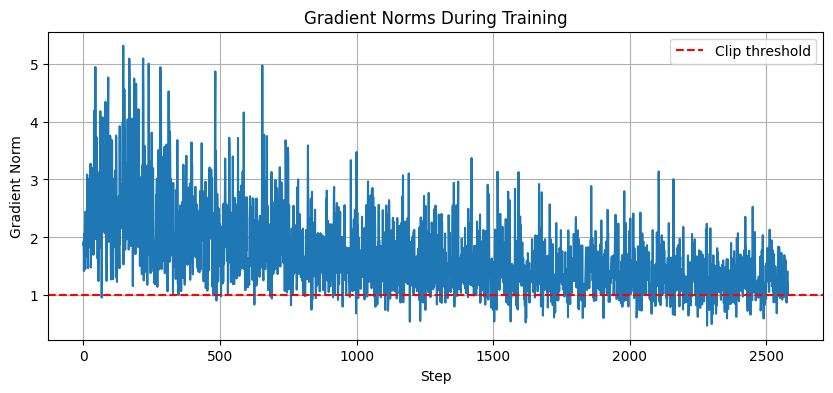

In [27]:
# Plot gradient norms
plt.figure(figsize=(10, 4))
plt.plot(gradient_norms)
plt.axhline(y=1.0, color='r', linestyle='--', label='Clip threshold')
plt.xlabel('Step')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norms During Training')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 5: Mixed Precision Training

In [28]:
# Enable mixed precision
from tensorflow.keras import mixed_precision

# Set global policy to mixed precision
# Note: This works best on GPUs with Tensor Cores (e.g., V100, A100)
try:
    mixed_precision.set_global_policy('mixed_float16')
    print(f"Mixed precision policy: {mixed_precision.global_policy().name}")
except:
    print("Mixed precision not available, using float32")

Mixed precision policy: mixed_float16


In [29]:
def create_mixed_precision_model():
    """Model compatible with mixed precision training."""
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        # Output layer must be float32 for numerical stability
        layers.Dense(10, activation='softmax', dtype='float32')
    ])
    return model

# Train with mixed precision
model_mp = create_mixed_precision_model()
optimizer_mp = keras.optimizers.Adam(learning_rate=0.001)

model_mp.compile(
    optimizer=optimizer_mp,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining with Mixed Precision...")
history_mp = model_mp.fit(train_ds, epochs=3, validation_data=val_ds, verbose=1)


Training with Mixed Precision...
Epoch 1/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8186 - loss: 0.5221 - val_accuracy: 0.8650 - val_loss: 0.3819
Epoch 2/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8614 - loss: 0.3815 - val_accuracy: 0.8724 - val_loss: 0.3516
Epoch 3/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8748 - loss: 0.3418 - val_accuracy: 0.8776 - val_loss: 0.3305


In [30]:
# Reset to default policy
mixed_precision.set_global_policy('float32')

---
## Part 6: Complete Custom Training Loop with All Features

In [31]:
class AdvancedTrainer:
    """Complete trainer with all advanced features."""

    def __init__(self, model, optimizer, loss_fn,
                 clip_norm=None, accumulation_steps=1, log_interval=100):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.clip_norm = clip_norm
        self.accumulation_steps = accumulation_steps
        self.log_interval = log_interval

        # Metrics
        self.train_loss = keras.metrics.Mean()
        self.train_acc = keras.metrics.SparseCategoricalAccuracy()
        self.val_loss = keras.metrics.Mean()
        self.val_acc = keras.metrics.SparseCategoricalAccuracy()

        # Gradient accumulation
        self.accumulated_gradients = None
        self.accum_step = 0

        # History
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def _init_accumulation(self):
        self.accumulated_gradients = [tf.zeros_like(v) for v in self.model.trainable_variables]
        self.accum_step = 0

    @tf.function
    def _train_step(self, x, y):
        with tf.GradientTape() as tape:
            predictions = self.model(x, training=True)
            loss = self.loss_fn(y, predictions)

        gradients = tape.gradient(loss, self.model.trainable_variables)
        return loss, predictions, gradients

    def train_step(self, x, y):
        loss, predictions, gradients = self._train_step(x, y)

        # Accumulate gradients
        if self.accumulated_gradients is None:
            self._init_accumulation()

        for i, grad in enumerate(gradients):
            if grad is not None:
                self.accumulated_gradients[i] = self.accumulated_gradients[i] + grad / self.accumulation_steps

        self.accum_step += 1

        # Apply gradients
        if self.accum_step >= self.accumulation_steps:
            if self.clip_norm:
                self.accumulated_gradients, _ = tf.clip_by_global_norm(
                    self.accumulated_gradients, self.clip_norm)

            self.optimizer.apply_gradients(zip(self.accumulated_gradients, self.model.trainable_variables))
            self._init_accumulation()

        self.train_loss.update_state(loss)
        self.train_acc.update_state(y, predictions)
        return loss

    def validate(self, val_ds):
        self.val_loss.reset_state()
        self.val_acc.reset_state()

        for x, y in val_ds:
            predictions = self.model(x, training=False)
            loss = self.loss_fn(y, predictions)
            self.val_loss.update_state(loss)
            self.val_acc.update_state(y, predictions)

        return self.val_loss.result(), self.val_acc.result()

    def fit(self, train_ds, val_ds, epochs):
        for epoch in range(epochs):
            start_time = time.time()
            self.train_loss.reset_state()
            self.train_acc.reset_state()

            for step, (x, y) in enumerate(train_ds):
                self.train_step(x, y)

                if (step + 1) % self.log_interval == 0:
                    print(f"  Step {step+1}: loss={self.train_loss.result():.4f}")

            val_loss, val_acc = self.validate(val_ds)

            self.history['train_loss'].append(self.train_loss.result().numpy())
            self.history['train_acc'].append(self.train_acc.result().numpy())
            self.history['val_loss'].append(val_loss.numpy())
            self.history['val_acc'].append(val_acc.numpy())

            epoch_time = time.time() - start_time
            print(f"Epoch {epoch+1}/{epochs} - {epoch_time:.2f}s - "
                  f"loss: {self.train_loss.result():.4f} - acc: {self.train_acc.result():.4f} - "
                  f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        return self.history

In [32]:
# Train with advanced trainer
model_adv = create_model()

trainer = AdvancedTrainer(
    model=model_adv,
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    clip_norm=1.0,
    accumulation_steps=2,
    log_interval=200
)

print("Training with Advanced Trainer...\n")
history_adv = trainer.fit(train_ds, val_ds, epochs=5)

Training with Advanced Trainer...

  Step 200: loss=0.8269
  Step 400: loss=0.6721
  Step 600: loss=0.6008
  Step 800: loss=0.5655
Epoch 1/5 - 21.03s - loss: 0.5575 - acc: 0.8050 - val_loss: 0.4107 - val_acc: 0.8594
  Step 200: loss=0.4271
  Step 400: loss=0.4108
  Step 600: loss=0.4043
  Step 800: loss=0.3992
Epoch 2/5 - 20.87s - loss: 0.3973 - acc: 0.8581 - val_loss: 0.3617 - val_acc: 0.8670
  Step 200: loss=0.3694
  Step 400: loss=0.3650
  Step 600: loss=0.3578
  Step 800: loss=0.3557
Epoch 3/5 - 20.52s - loss: 0.3551 - acc: 0.8710 - val_loss: 0.3850 - val_acc: 0.8528
  Step 200: loss=0.3432
  Step 400: loss=0.3365
  Step 600: loss=0.3329
  Step 800: loss=0.3281
Epoch 4/5 - 20.55s - loss: 0.3285 - acc: 0.8810 - val_loss: 0.3259 - val_acc: 0.8844
  Step 200: loss=0.3135
  Step 400: loss=0.3064
  Step 600: loss=0.3047
  Step 800: loss=0.3056
Epoch 5/5 - 20.54s - loss: 0.3061 - acc: 0.8881 - val_loss: 0.3379 - val_acc: 0.8786


---
## Summary

| Component | Purpose | Key Features |
|-----------|---------|-------------|
| **CustomSGD** | Basic optimizer | Momentum, velocity tracking |
| **CustomAdam** | Adaptive optimizer | First/second moments, bias correction |
| **AdamW** | Adam + weight decay | Decoupled regularization |
| **GradientTape** | Manual differentiation | Full control over gradients |
| **Gradient Accumulation** | Large effective batch | Memory-efficient training |
| **Gradient Clipping** | Prevent explosions | Clip by global norm |
| **Mixed Precision** | Faster training | FP16 forward, FP32 gradients |